In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from matplotlib.lines import Line2D
import seaborn as sns

from datetime import datetime as dt
from datetime import timedelta
import os

import matplotlib.cm as cm
import matplotlib.ticker as ticker
pd.options.mode.chained_assignment = None 

In [2]:
import matplotlib
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

In [3]:
folder_name = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/Figures/RangeQueries/"

In [4]:
def read(dataset, compare):
    df = pd.read_csv(filename, header = 0)
    #return getBins(df)
    return df


In [5]:
def get_used_attrs(df):
    attrs = []
    for i in df['queryText'].unique():
        splitted = i.split(' ')
        for s in splitted:
            if "=" in s:
                continue
            if s.isnumeric():
                continue
            if '-' in s:
                continue
            if 'and' in s:
                continue
            if s not in attrs:
                attrs.append(s)
    print(attrs)
    return len(attrs)
    print("{} Distinct attributes used in predicates".format(len(attrs)))
    

In [6]:
def preprocess(df, p, keepAll = False):
    df = df[df['numPredicates'] != 1]
    for k, v in df.iterrows():
        s = v['queryText'].split(' ')
        for i in s:
            if ',' in i:
                low = i.split(',')[0]
                high = i.split(',')[1]
        df.loc[k,'rangeSizes'] = int(high) - int(low)
    #if 'relError' in df.columns[df.dtypes == 'object']:
    #    df.loc[:,'relError'] = df['relError'].apply(lambda x: x.replace(',','.')).astype({'relError': float})
    #if 'epsError' in df.columns[df.dtypes == 'object']:
    #df.loc[:,'epsError'] = df.loc[:,'epsError'].apply(lambda x: x.replace(',','.')).astype({'epsError': float})
    df.loc[:,'Sketch Memory (MB)'] = df.loc[:,'memUsageSynopsis']/(8e6)
    df.loc[:,'Dataset Memory (MB)'] = df.loc[:,'memUsageDataset']/(8e6)
    df.loc[:,'Speedup'] = df.loc[:,'exactTime']/df.loc[:,'estTime']
    df.loc[:,'Time Est (ms)'] =  df.loc[:,'estTime']
    df.loc[:,'Avg Update Time (ms)'] =  df.loc[:,'Avg Update Time']
    df['Ingestion Time (s)'] = 0
    df.loc[:,'Ingestion Time (s)'] = df.loc[:, "Avg Update Time (ms)"]*df.loc[:,"streamSize"]/1000
    df.loc[:,'Time exact (ms)'] = df.loc[:,'exactTime']
    df.loc[:,'relMemFootprint'] = df.loc[:,'Sketch Memory (MB)']/df.loc[:,'Dataset Memory (MB)']
    df.loc[:, 'thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    df.loc[:,'RAM'] = df.loc[:,'memUsageSynopsis']/(8e6)
    if not keepAll:
        df = df[df['numPredicates'] == p]
    df.loc[:,'altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                       abs(df.loc[:,'case2Estimate'] - df.loc[:, 'exactAnswer']),
                                       df['absError'])
    df.loc[:, 'altEpsError'] = df['altAbsError']/df['streamSize'] # Alternative epsError.
    df.loc[:,'altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                           df.loc[:,'exactAnswer'],
                                           abs(df.loc[:,'estimate'] - df.loc[:,'exactAnswer']))
    df.loc[:, 'altNullEpsError'] = df['altNullAbsError']/df['streamSize']
    df['d'] = 0
    df['w'] = 0
    df['B'] = 0
    df['b'] = 0
    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'] = pars[0]
            df.loc[k, 'w'] = pars[1]
            df.loc[k, 'B'] = pars[2]
            df.loc[k, 'b'] = pars[3]
    
    df['histSetting'] = (df['setting'] + df['RAM'].astype(str))
    for i, v in df.iterrows():
        setting = v['histSetting'].replace("p0.0", "p").replace("n0.0", "n").replace(".0", "")
        if (setting == 'Sketch0Cap'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}0_{\cap}$'
        elif (setting == 'Sketch0Min'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}0_{\min}$'
        elif (setting == 'OmniSketch0'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1$'
        elif (setting == 'OmniSketch1'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (1 MB)$'
        elif (setting == 'OmniSketch10'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (10 MB)$'
        elif (setting == 'OmniSketch50'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (50 MB)$'
        elif (setting == 'OmniSketch100'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (100 MB)$'
        elif (setting == 'OmniSketch200'):
            df.loc[i, 'histSetting'] =  r'$\mathbb{S}1 (200 MB)$'
        elif (setting == 'Hydra1'):
            df.loc[i, 'histSetting'] =  r'Hydra (1 MB)'
        elif (setting == 'Hydra10'):
            df.loc[i, 'histSetting'] =  r'Hydra (10 MB)'
        elif (setting == 'Hydra50'):
            df.loc[i, 'histSetting'] =  r'Hydra (50 MB)'
        elif (setting == 'Hydra100'):
            df.loc[i, 'histSetting'] =  r'Hydra (100 MB)'
        elif (setting == 'Hydra200'):
            df.loc[i, 'histSetting'] =  r'Hydra (200 MB)'
        #else:
        #    print(setting)
    df['histSetting2'] = "l: {}, p: {}:".format(df['rangeSizes'].astype(str),
                                                       df['numPredicates'].astype(str))
    
    return df

In [7]:
def preprocessPoint(df, p, keepAll=False):
    def replace_comma_with_dot_and_convert_to_float(column_name):
        if column_name in df.columns[df.dtypes == 'object']:
            df[column_name] = df[column_name].str.replace(',', '.').astype({column_name: float})

    replace_comma_with_dot_and_convert_to_float('relError')
    replace_comma_with_dot_and_convert_to_float('epsError')

    df['Sketch Memory (MB)'] = df['memUsageSynopsis'] / 1e6
    df['Dataset Memory (MB)'] = df['memUsageDataset'] / 1e6
    df['Speedup'] = df['exactTime'] / df['estTime']
    df['Time Est (ms)'] = df['estTime']
    df['Avg Update Time (ms)'] = df['Avg Update Time']
    df.loc[:,'RAM'] = df.loc[:,'memUsageSynopsis']/(8e6)
    df['Time exact (ms)'] = df['exactTime']
    df['Ingestion Time (s)'] = 0
    df.loc[:,'Ingestion Time (s)'] = df.loc[:, "Avg Update Time (ms)"]*df.loc[:,"streamSize"]/1000
    df['relMemFootprint'] = df['Sketch Memory (MB)'] / df['Dataset Memory (MB)']
    df['thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    #df['RAM'] = df['RAM'] / (8e6)

    if not keepAll:
        df = df[df['numPredicates'] == p]

    df['altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                 abs(df['case2Estimate'] - df['exactAnswer']),
                                 df['absError'])
    df['altEpsError'] = df['altAbsError'] / df['streamSize']  # Alternative epsError.
    df['altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                     df['exactAnswer'],
                                     abs(df['estimate'] - df['exactAnswer']))
    df['altNullEpsError'] = df['altNullAbsError'] / df['streamSize']
    df['d'], df['w'], df['B'], df['b'] = 0, 0, 0, 0

    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'], df.loc[k, 'w'], df.loc[k, 'B'], df.loc[k, 'b'] = pars

    df['histSetting'] = df['setting'] + df['RAM'].astype(str)
    setting_map = {
        'Sketch0Cap': r'$\mathbb{S}0_{\cap}$',
        'Sketch0Min': r'$\mathbb{S}0_{\min}$',
        'OmniSketch10.0': r'$\mathbb{S}1 (10 MB)$',
        'OmniSketch50.0': r'$\mathbb{S}1 (50 MB)$',
        'OmniSketch100.0': r'$\mathbb{S}1 (100 MB)$',
        'OmniSketch200.0': r'$\mathbb{S}1 (200 MB)$',
        'Hydra10.0': 'Hydra (10 MB)',
        'Hydra50.0': 'Hydra (50 MB)',
        'Hydra100.0': 'Hydra (100 MB)',
        'Hydra200.0': 'Hydra (200 MB)'
    }
    df['histSetting'] = df['histSetting'].replace(setting_map)

    for numAttrs in df['numAttributes'].unique():
        dfa = df[df['numAttributes'] == numAttrs]
        usedAttrs = get_used_attrs(dfa)
        df.loc[df['numAttributes'] == numAttrs, 'numAttributesInWorkload'] = usedAttrs

    return df

In [8]:
dataset = "SNMP"

In [9]:
#filename = "output/results_Compare Estimators_CAIDA_2023-07-14.csv"
#filename = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/outputODC/rangeQs/results_Range Queries_SNMP_2023-08-24_range_Rep2.csv"
filename = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/outputODC/FinalRangeQuery/results_Range Queries_SNMP_2023-08-25_range_Rep1.csv"

df = read(dataset, True)
p = 2
df = preprocess(df, p, True)


In [11]:
#filename = "output/results_Compare Estimators_CAIDA_2023-07-14.csv"
#filename = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/outputODC/rangeQs/results_Range Queries_SNMP_2023-08-24_range_Rep2.csv"
filename = "C:/Users/s162378/OneDrive - TU Eindhoven/Documents/GitHub/DSCM/outputODC/FinalRangeQuery/results_Range Queries_SNMP_2023-08-27_Rep1.csv"

df_point = read(dataset, True)
p = 2
df_point = preprocessPoint(df_point, p, True)


['ifOutOctets', 'ifOutErrors']
['ifOutOctets', 'ifOutDiscards', 'ifOutErrors']
['ifOutOctets', 'ifOutDiscards', 'ifOutErrors', 'ifOutUcastPkts']
['ifOutOctets', 'ifOutDiscards', 'ifInOctets', 'ifOutUcastPkts', 'ifOutErrors']
['ifOutOctets', 'ifOutDiscards', 'ifInUcastPkts', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifInErrors', 'ifOutDiscards', 'ifOutOctets', 'ifInUcastPkts', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifInDiscards', 'ifOutOctets', 'ifInErrors', 'ifOutDiscards', 'ifInUcastPkts', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']


In [12]:

# Define a dictionary to map 'histSetting' to marker and color
histSetting_style_dict = {
    '$\\mathbb{S}0_{\\min}$': {'marker': 'o', 'color': 'blue', 'linestyle': '-'},
    '$\\mathbb{S}0_{\\cap}$': {'marker': 's', 'color': 'green', 'linestyle': '--'},
    '$\\mathbb{S}1 (1 MB)$': {'marker': '^', 'color': 'yellow', 'linestyle': '-'},
    '$\\mathbb{S}1 (10 MB)$': {'marker': '^', 'color': 'orange', 'linestyle': '-'},
    '$\\mathbb{S}1 (50 MB)$': {'marker': 'D', 'color': 'red', 'linestyle': '-'},
    '$\\mathbb{S}1 (100 MB)$': {'marker': 'v', 'color': 'purple', 'linestyle': '-'},
    '$\\mathbb{S}1 (200 MB)$': {'marker': '*', 'color': 'black', 'linestyle': '-'},
    'Hydra (1 MB)': {'marker': 'X', 'color': 'lime', 'linestyle': '-.'},
    'Hydra (10 MB)': {'marker': 'X', 'color': 'lime', 'linestyle': '-.'},
    'Hydra (50 MB)': {'marker': '+', 'color': 'blue', 'linestyle': '-.'},
    'Hydra (100 MB)': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-.'},
    'Hydra (200 MB)': {'marker': 'H', 'color': 'grey', 'linestyle': '-.'},
    'OmniSketch_2': {'marker': 'D', 'color': 'brown', 'linestyle': ':'},
    'OmniSketch_3': {'marker': 's', 'color': 'darkblue', 'linestyle': '-.'},
    'Hydra_2': {'marker': 'o', 'color': 'teal', 'linestyle': '-'},
    'Hydra_3': {'marker': 'v', 'color': 'indigo', 'linestyle': '--'},
    'OmniSketch_2_50': {'marker': 'X', 'color': 'gold', 'linestyle': '-.'},
    'OmniSketch_3_50': {'marker': 'P', 'color': 'pink', 'linestyle': ':'},
    'Hydra_2_50': {'marker': 's', 'color': 'darkgreen', 'linestyle': '-'},
    'Hydra_3_50': {'marker': '*', 'color': 'coral', 'linestyle': '--'},
    'OmniSketch_2_100': {'marker': 'D', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_3_100': {'marker': 'H', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_2_100': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'Hydra_3_100': {'marker': 'o', 'color': 'darkred', 'linestyle': '--'},
    'Hydra_4': {'marker': 'X', 'color': 'darkcyan', 'linestyle': '-.'},
    'OmniSketch_4': {'marker': 'D', 'color': 'deeppink', 'linestyle': ':'},
    'Hydra_4_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_4_50': {'marker': 'H', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_4_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-.'},
    'OmniSketch_4_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': ':'},
    'Hydra_5': {'marker': 'X', 'color': 'darkcyan', 'linestyle': '-'},
    'OmniSketch_5': {'marker': 'D', 'color': 'deeppink', 'linestyle': '--'},
    'Hydra_5_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-.'},
    'OmniSketch_5_50': {'marker': 'H', 'color': 'crimson', 'linestyle': ':'},
    'Hydra_5_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-'},
    'OmniSketch_5_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': '--'},
    'Hydra_6': {'marker': 'X', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_6': {'marker': 'D', 'color': 'gray', 'linestyle': ':'},
    'Hydra_6_50': {'marker': '+', 'color': 'darkblue', 'linestyle': '-'},
    'OmniSketch_6_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_6_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_6_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': ':'},
    'Hydra_7': {'marker': '^', 'color': 'lime', 'linestyle': '-'},
    'OmniSketch_7': {'marker': 'D', 'color': 'indigo', 'linestyle': '--'},
    'Hydra_7_50': {'marker': 'X', 'color': 'crimson', 'linestyle': '-.'},
    'OmniSketch_7_50': {'marker': 'H', 'color': 'gold', 'linestyle': ':'},
    'Hydra_7_100': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-'},
    'OmniSketch_7_100': {'marker': 'v', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_8': {'marker': 'o', 'color': 'brown', 'linestyle': '-.'},
    'OmniSketch_8': {'marker': 's', 'color': 'darkblue', 'linestyle': ':'},
    'Hydra_8_50': {'marker': '+', 'color': 'darkgreen', 'linestyle': '-'},
    'OmniSketch_8_50': {'marker': 'H', 'color': 'coral', 'linestyle': '--'},
    'Hydra_8_100': {'marker': 'P', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_8_100': {'marker': 'v', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_9': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'OmniSketch_9': {'marker': 'D', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_9_50': {'marker': 'X', 'color': 'darkblue', 'linestyle': '-.'},
    'OmniSketch_9_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': ':'},
    'Hydra_9_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-'},
    'OmniSketch_9_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': '--'},
    'Hydra_10': {'marker': 'o', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_10': {'marker': 's', 'color': 'gray', 'linestyle': ':'},
    'Hydra_10_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_10_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_10_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_10_100': {'marker': 'v', 'color': 'deeppink', 'linestyle': ':'}
}

# Define a dictionary to map 'aggr' to linestyle
aggr_dict = {
    'altEpsError': '-',
    'IT': '-',
    'execTime': ':',
    
    'RAM': 'dotted'
}

# Get the unique MB values from the 'histSetting' column
#unique_MB_values = [int(x.split(' ')[1].replace('(', '')) for x in df['histSetting'] if 'MB' in x]

# Calculate the normalized values for the color map
#normalized_MB = [(MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values)) for MB in unique_MB_values]



# Function to get color based on 'histSetting'
def get_color(histSetting, psetting = False):
    if psetting:
        if 'Hydra' in histSetting:
        # Create a color map based on the MB values
            color_map = cm.get_cmap('plasma')
        elif 'Omni' in histSetting:
            color_map = cm.get_cmap('cividis')
        else:
            print("No colormap defined for setting {}".format(histSetting))
        p = int(histSetting.split('_')[1].replace('_', ''))
        normalized_p_value = (p - 2) / (1)
        return color_map(normalized_p_value)
    
    if '{S}0' in histSetting:
        return histSetting_style_dict.get(histSetting)['color']
    if 'Hydra' in histSetting:
        # Create a color map based on the MB values
        color_map = cm.get_cmap('tab20')
    elif '{S}1' in histSetting:
        color_map = cm.get_cmap('viridis')
    else:
        print("No colormap defined for setting {}".format(histSetting))
    MB = int(histSetting.split(' ')[1].replace('(', ''))
    normalized_MB_value = (MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values))
    return color_map(normalized_MB_value)


In [13]:
all_ids = []

for i in df['numPredicates'].unique():
    if i < 5:
        df1 = df[df['numPredicates'] == i]
        df1 = df1[df1['numAttributes'] == i]
        ids = df1['queryText'].unique()
        idslen = len(ids)
        previdslen = len(all_ids)
        for j in ids:
            all_ids.append(j)
        print("all ids is now {} and should be {}".format(len(all_ids), idslen + previdslen))
df_cons = df[df['queryText'].isin(all_ids)]

all ids is now 105 and should be 105
all ids is now 120 and should be 120
all ids is now 120 and should be 120


In [14]:
all_ids = []

for i in df_point['numPredicates'].unique():
    if i < 5:
        df1_point = df_point[df_point['numPredicates'] == i]
        df1_point = df1_point[df1_point['numAttributes'] == i]
        ids = df1_point['queryText'].unique()
        idslen = len(ids)
        previdslen = len(all_ids)
        for j in ids:
            all_ids.append(j)
        print("all ids is now {} and should be {}".format(len(all_ids), idslen + previdslen))
df_cons_point = df_point[df_point['queryText'].isin(all_ids)]

all ids is now 97 and should be 97
all ids is now 113 and should be 113
all ids is now 117 and should be 117


In [15]:
dfl = df_cons[df_cons['rangeSizes'] == df_cons['rangeSizes'].max()]
dfl = dfl[dfl['B'] == 1000]

In [16]:
dfl_point = df_cons_point#[df_cons_point['rangeSizes'] == df_cons_point['rangeSizes'].max()]
dfl_point = dfl_point[dfl_point['B'] == 1000]

In [17]:
np.log(df['rangeSizes'].max())/np.log(2)

25.0

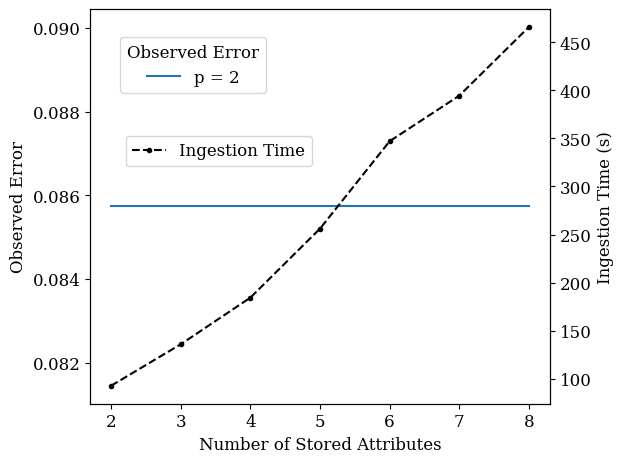

In [18]:
dfl = dfl[dfl['numPredicates'] == 2]
grouped = dfl.groupby(['numAttributes', 'numPredicates'])['altEpsError'].mean().unstack(['numPredicates'])
dfl2 = dfl[dfl['numPredicates'] == 2]
grouped2 = dfl2.groupby(['numAttributes', 'numPredicates'])['Ingestion Time (s)'].mean().unstack(['numPredicates'])
fig, ax1 = plt.subplots()

# Plotting the first dataset with legend
lines = ax1.plot(grouped)
legend_labels = [f'p = {val}' for val in grouped.columns]
ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
ax1.set_ylabel('Observed Error')
ax1.set_xlabel('Number of Stored Attributes')

ax2 = ax1.twinx()

# Plotting the second dataset with legend
lines2 = ax2.plot(grouped2, color='black', marker='.', linestyle='--')
legend_labels2 = [f'Ingestion Time' for val in grouped2.columns]
#ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set3.colors))
ax2.set_ylabel('Ingestion Time (s)')

# Adding the custom legend
ax1.legend(lines, legend_labels, title='Observed Error', bbox_to_anchor=(0.4,0.95))
ax2.legend(lines2, legend_labels2, bbox_to_anchor=(0.5,0.7))
plt.xticks(rotation=45)
plt.tight_layout()

# Save and display the plot
plt.savefig("plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [19]:
dfl_point['memUsageSynopsis']/8e6


97       1.534554
98       1.534554
99       1.534554
100      1.534554
101      1.534554
           ...   
41387    6.169868
41438    6.169868
41453    6.169868
41460    6.169868
41560    6.169868
Name: memUsageSynopsis, Length: 795, dtype: float64

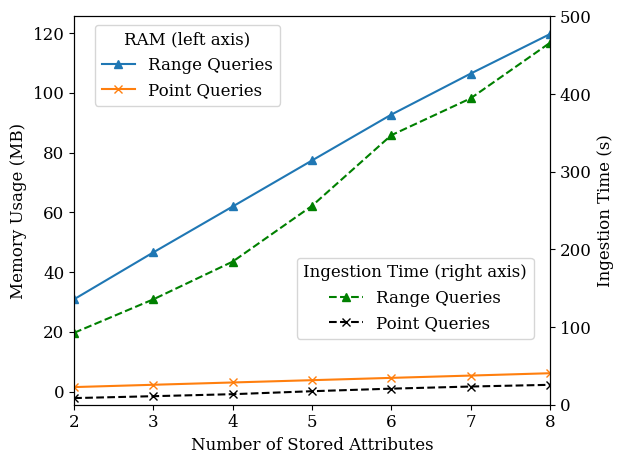

In [21]:
grouped = dfl.groupby(['numAttributes'])['RAM'].mean()#.unstack(['numPredicates'])
dfl2 = dfl[dfl['numPredicates'] == 2]
grouped2 = dfl2.groupby(['numAttributes', 'numPredicates'])['Ingestion Time (s)'].mean().unstack(['numPredicates'])

grouped_point = dfl_point.groupby(['numAttributes'])['RAM'].mean()#.unstack(['numPredicates'])
dfl2_point = dfl_point[dfl_point['numPredicates'] == 2]
grouped2_point = dfl2_point.groupby(['numAttributes', 'numPredicates'])['Ingestion Time (s)'].mean().unstack(['numPredicates'])

fig, ax1 = plt.subplots()

# Plotting the first dataset with legend
lines = ax1.plot(grouped, marker='^')

lines += ax1.plot(grouped_point, marker='x')
legend_labels = ['Range Queries', 'Point Queries']
ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
ax1.set_ylabel('Memory Usage (MB)')
ax1.set_xlabel('Number of Stored Attributes')

ax1.set_xlim(2,8)
ax2 = ax1.twinx()
ax2.set_ylim(0,500)

# Plotting the second dataset with legend
#ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
lines2 = ax2.plot(grouped2, color='green', marker='^', linestyle='--')
lines2 += ax2.plot(grouped2_point, color='black', marker='x', linestyle='--')

#legend_labels2 = ['Range Queries', 'Point Queries']
#ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set3.colors))
ax2.set_ylabel('Ingestion Time (s)')

# Adding the custom legend
ax1.legend(lines, legend_labels,title='RAM (left axis)', bbox_to_anchor=(0.45,1))
ax2.legend(lines2, legend_labels, title='Ingestion Time (right axis)',bbox_to_anchor=(0.45,0.4))

plt.xticks(rotation=45)
plt.tight_layout()

# Save and display the plot
plt.savefig(folder_name +"ramAndIT.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [64]:
df_point['Avg Update Time (ms)']*df_point['streamSize']/1000

0         7.529
1         7.529
2         7.529
3         7.529
4         7.529
          ...  
53435    30.553
53436    30.553
53437    30.553
53438    30.553
53439    30.553
Length: 53440, dtype: float64

In [66]:
grouped2_point

numPredicates,2
numAttributes,
2,8.540
3,10.992
4,13.574
5,17.390
6,20.692
7,23.427
8,25.636


In [325]:
df.groupby(['numAttributes', 'numPredicates'])['altEpsError'].mean()

numAttributes  numPredicates
2              2                0.068593
3              2                0.059374
               3                0.031439
4              2                0.074911
               3                0.043158
5              2                0.090603
               3                0.053992
6              2                0.098089
               3                0.072098
               4                0.029280
7              2                0.095345
               3                0.072098
               4                0.029280
8              2                0.094150
               3                0.072098
               4                0.029280
Name: altEpsError, dtype: float64

In [337]:
2 * 0.1 *1

0.2

In [330]:
dflp2 = df[df['numPredicates'] == 4]
len(dflp2['queryText'].unique())

1

ValueError: too many values to unpack (expected 1)

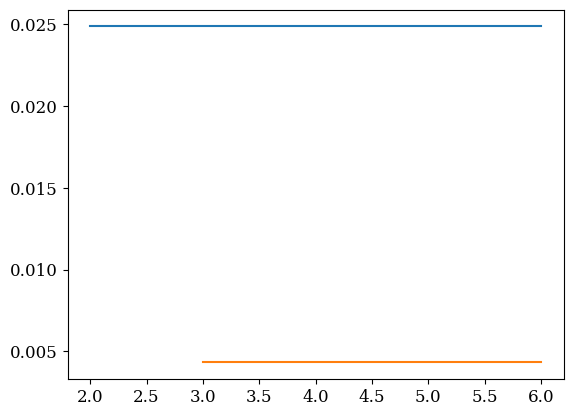

In [238]:
grouped = dfl.groupby(['numAttributes', 'numPredicates'])['altEpsError'].mean().unstack(['numPredicates'])
grouped2 = dfl.groupby(['numAttributes', 'numPredicates'])['Ingestion Time (s)'].mean().unstack(['numPredicates'])
fig, ax1 = plt.subplots()
ax1.plot(grouped)
ax1.set_prop_cycle(plt.cycler('color', plt.cm.Set1.colors))
ax1.set_ylabel('Observed Error')
ax1.set_xlabel('Number of Stored Attributes')
ax2 = ax1.twinx()

ax2.set_prop_cycle(plt.cycler('color', plt.cm.Set3.colors))
ax2.plot(grouped2)
ax2.set_ylabel('Ingestion Time (s)')
ax1.legend()
ax2.legend()
#plt.title('Observed Error by B for different values of p')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(folder_name + "{}_{}.pdf".format("RangeQueriesMemPerB", dataset), format="pdf", bbox_inches="tight" )
plt.show()

    

In [234]:
df['streamSize']

1        8262313
3        8262313
8        8262313
12       8262313
17       8262313
          ...   
37212    8262313
37220    8262313
37222    8262313
37223    8262313
37224    8262313
Name: streamSize, Length: 14447, dtype: int64

In [235]:
dfl['B'].unique()

array([2500], dtype=int64)

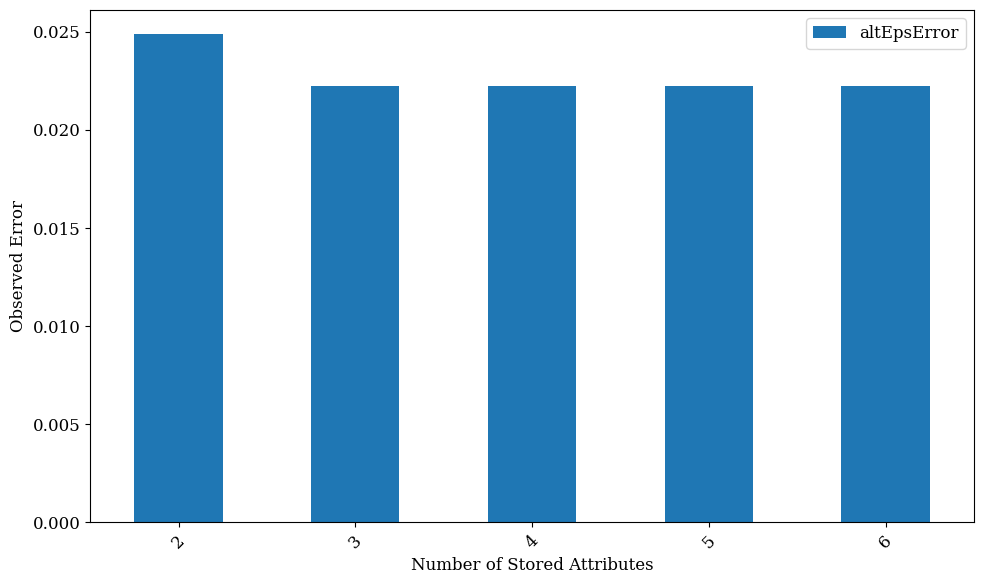

In [236]:
grouped = dfl.groupby(['numAttributes'])['altEpsError'].mean()#.unstack(['numPredicates'])
#grouped2 = dfl.groupby(['B', 'numPredicates'])['Avg Update Time (ms)'].mean().unstack(['numPredicates'])

ax1 = grouped.plot(kind='bar', figsize=(10, 6))
ax1.set_ylabel('Observed Error')
ax1.set_xlabel('Number of Stored Attributes')
#ax2 = ax1.twinx()
#ax2 = grouped2.plot(kind='bar', figsize=(10, 6))
#ax2.set_ylabel('Ingestion Time (ms)')
plt.legend()
#plt.title('Observed Error by B for different values of p')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(folder_name + "{}_{}.pdf".format("RangeQueriesITMem", dataset), format="pdf", bbox_inches="tight" )
plt.show()

    

In [123]:
df['b'].unique()

array([20, 21, 22], dtype=int64)

In [124]:
df500 = df[df['B'] == 500]
df500['b'].unique()

array([20], dtype=int64)

In [125]:
d = 3
w = 30
Bs = [500, 1000, 1500, 2000, 2500]
bs = [20, 21, 22, 23, 24]
p = 8

maxUsages = []
actUsages = []
for i in range(len(Bs)):
    maxUsg = d * w * p * 34 * (32 + Bs[i]*(32*3 + bs[i] + 1))
    dfB = df[df['B'] == Bs[i]]
    maxUsages.append(maxUsg/8e6)
    actUsages.append((dfB['memUsageSynopsis']/8e6).unique())
    print("Max usage for B = {} is {}, actual usage is {}".format(Bs[i], maxUsg/8e6, (dfB['memUsageSynopsis']/8e6).unique()))

    
for i in range(len(maxUsages) -1):
    print("Usage for B = {} over B = {}".format(Bs[i+1], Bs[i]))
    print("Ratio max Usages: {}".format(maxUsages[i + 1]/ maxUsages[i]))
    print("Ratio act Usages: {}".format(actUsages[i + 1]/ actUsages[i]))
    print("\n")

Max usage for B = 500 is 179.10792, actual usage is [50.37321862]
Max usage for B = 1000 is 361.17792, actual usage is [119.49649875]
Max usage for B = 1500 is 546.30792, actual usage is [186.30576038]
Max usage for B = 2000 is 734.49792, actual usage is []
Max usage for B = 2500 is 925.74792, actual usage is []
Usage for B = 1000 over B = 500
Ratio max Usages: 2.0165379621403674
Ratio act Usages: [2.37222282]


Usage for B = 1500 over B = 1000
Ratio max Usages: 1.5125728615968552
Ratio act Usages: [1.5590897]


Usage for B = 2000 over B = 1500
Ratio max Usages: 1.3444760603141175
Ratio act Usages: []


Usage for B = 2500 over B = 2000
Ratio max Usages: 1.260381949073457
Ratio act Usages: []




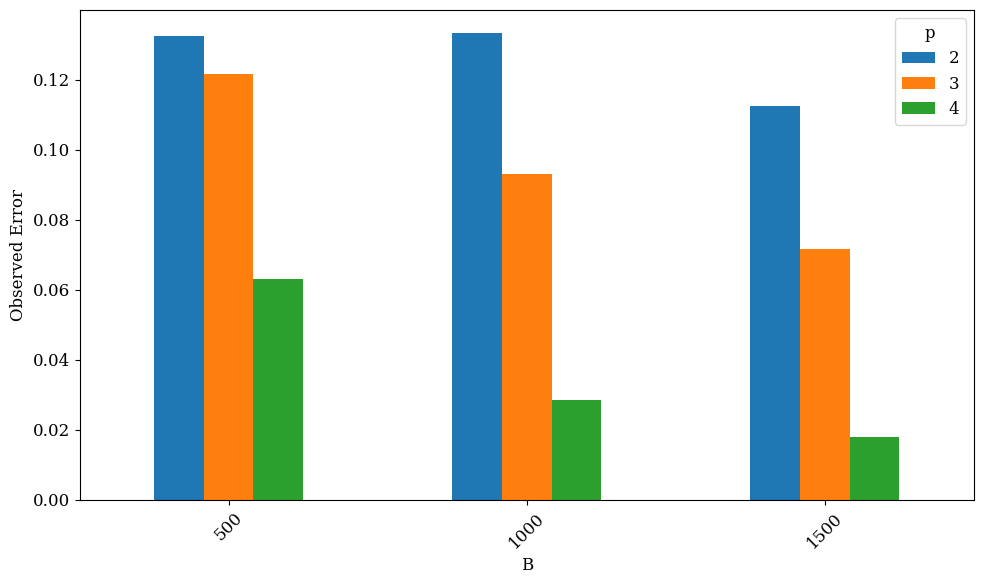

In [126]:
grouped = dfl.groupby(['B', 'numPredicates'])['altEpsError'].mean().unstack(['numPredicates'])

ax = grouped.plot(kind='bar', figsize=(10, 6))
ax.set_ylabel('Observed Error')
ax.set_xlabel('B')
plt.legend(title='p')
#plt.title('Observed Error by B for different values of p')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(folder_name + "{}_{}.pdf".format("RangeQueriesObservedError", dataset), format="pdf", bbox_inches="tight" )
plt.show()

    

In [100]:
df['memUsageDataset']/8e6

1       297.443268
2       297.443268
3       297.443268
4       297.443268
5       297.443268
           ...    
3305    297.443268
3308    297.443268
3312    297.443268
3313    297.443268
3314    297.443268
Name: memUsageDataset, Length: 1497, dtype: float64

In [44]:
7674590384 - 2**32

3379623088

In [45]:
-915344208 + 2**32

3379623088

In [77]:
2**10

1024

In [19]:
df5000 = df[df['B']== 5000]
df10000 = df[df['B']== 10000]

In [20]:
df5000['altEpsError'].mean()

0.46744841224319267

In [21]:
df10000['altEpsError'].mean()

0.46762426325555195

In [110]:
df5000 = df[df['B']== 10000]
dfyes = df5000[df5000['B'] != df5000['intersectSize']]
dfno = df5000[df5000['B'] == df5000['intersectSize']]

In [111]:
dfyes['exactAnswer'].describe()

count      200.000000
mean       886.005000
std       2632.452718
min          1.000000
25%         28.000000
50%        172.500000
75%        546.750000
max      26636.000000
Name: exactAnswer, dtype: float64

In [112]:
dfno['exactAnswer'].describe()

count       786.000000
mean       2429.183206
std       12031.903546
min           1.000000
25%          15.000000
50%         108.500000
75%         801.250000
max      267148.000000
Name: exactAnswer, dtype: float64

In [101]:
cnt=0
for i in dfno['queryText'].unique():
    if i in dfyes['queryText'].unique():
        i
        #print(i)
    else:
         cnt+=1
print(cnt)

0


In [90]:
dfyes['queryText'].unique()

array(['ifOutErrors in 15602193,49156625 and ifOutOctets in 1822705673,1856260105',
       'ifOutUcastPkts in 239150124,272704556 and ifOutOctets in 2706219088,2739773520',
       'ifOutOctets in 405258989,438813421 and ifInOctets in 844234205,877788637',
       'ifOutDiscards in 107561572,141116004 and ifInOctets in 2758303365,2791857797',
       'ifOutDiscards in 492055,524823 and ifOutOctets in 3548402013,3548434781',
       'ifOutOctets in 3226947350,3260501782 and ifOutDiscards in 48275873,81830305 and ifOutErrors in 36202148,69756580',
       'ifOutUcastPkts in 4709292,38263724 and ifOutErrors in 64610064,98164496',
       'ifOutUcastPkts in 43228494,76782926 and ifInOctets in 1086268765,1119823197',
       'ifInOctets in 3681333362,3714887794 and ifOutOctets in 3685032019,3718586451',
       'ifOutErrors in 2454754,3503330 and ifOutUcastPkts in 76940133,77988709',
       'ifOutErrors in 29884787,63439219 and ifOutOctets in 2217159595,2250714027',
       'ifOutDiscards in 1019667

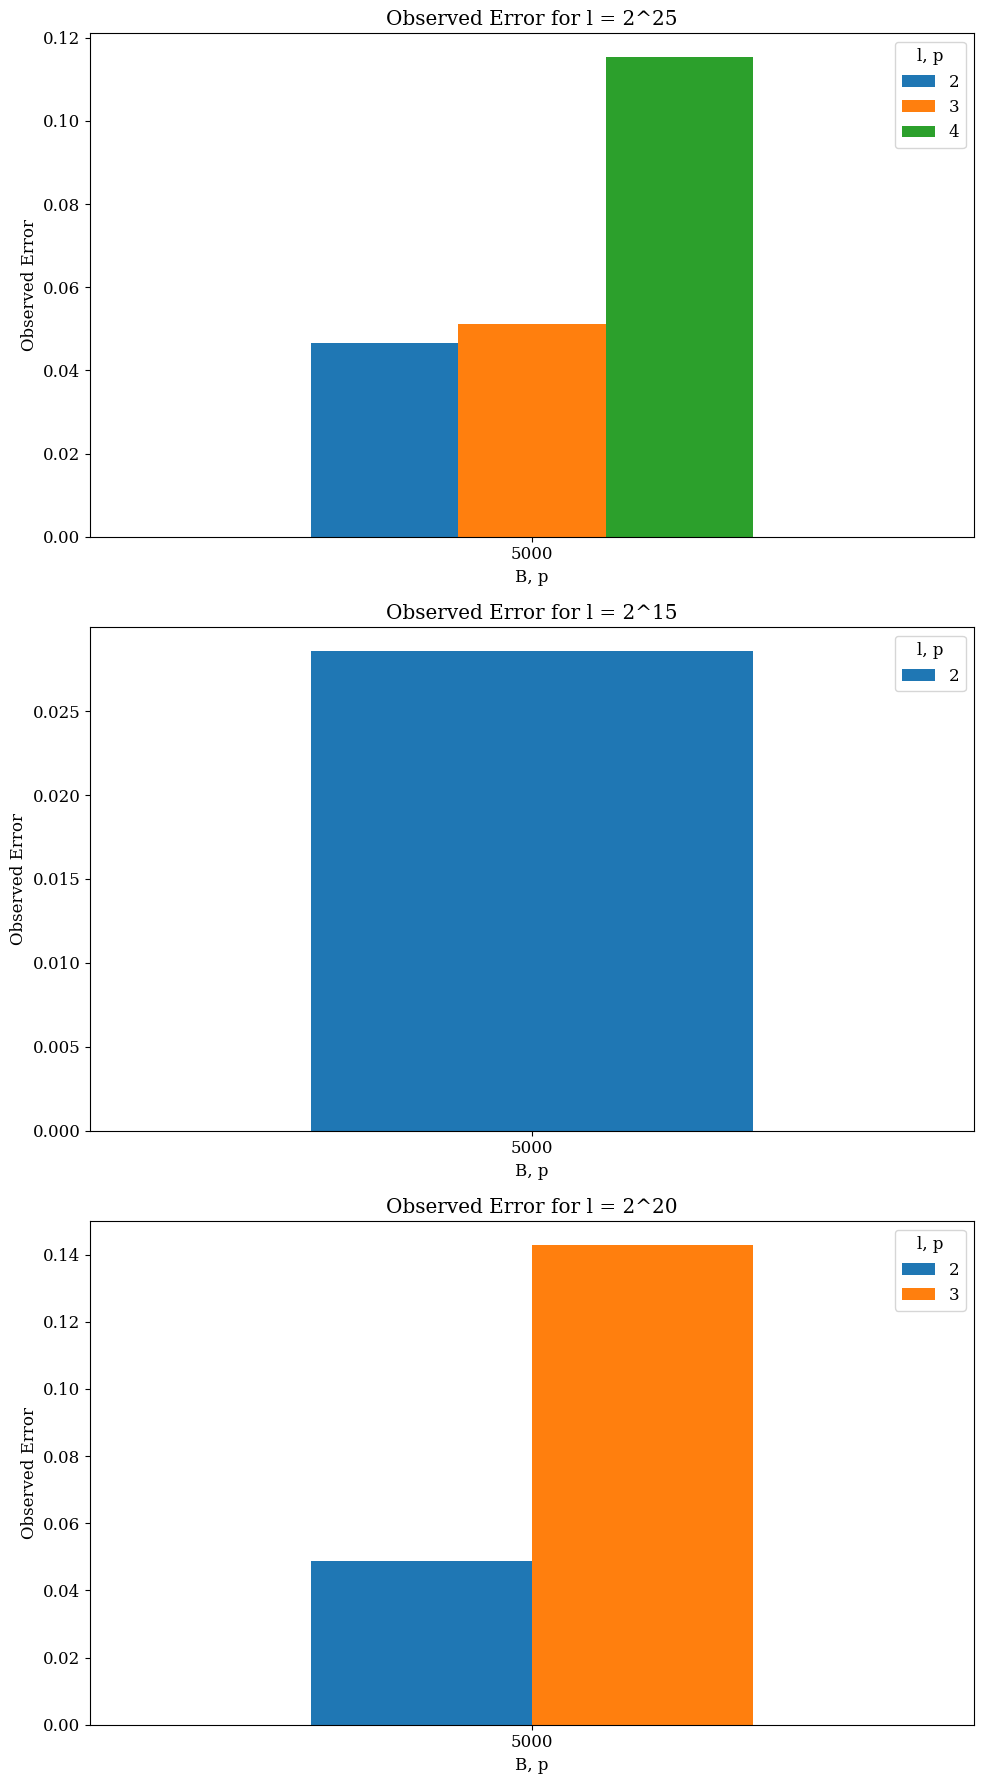

In [121]:
grouped = df.groupby(['B', 'numPredicates', 'rangeSizes'])['altEpsError'].mean().unstack(['rangeSizes', 'numPredicates'])

# Get unique rangeSizes values
range_sizes_values = df['rangeSizes'].unique()

# Create a figure with subplots
num_subplots = len(range_sizes_values)
fig, axes = plt.subplots(nrows=num_subplots, ncols=1, figsize=(10, 6 * num_subplots))

for i, size in enumerate(range_sizes_values):
    ax = axes[i]
    subset = grouped[size]
    subset.plot(kind='bar', ax=ax, legend=False)
    
    ax.set_ylabel('Observed Error')
    ax.set_xlabel('B, p')
    l = int(np.log(size)/np.log(2))
    ax.set_title(r"Observed Error for l = 2^{}".format(l))
    ax.set_xticklabels(subset.index, rotation=0)
    ax.set_xticks(range(len(subset)))
    ax.legend(title='l, p')

plt.tight_layout()
plt.show()

In [58]:
grouped = df.groupby(['B', 'numPredicates', 'rangeSizes'])['altEpsError'].mean().unstack(['rangeSizes', 'numPredicates'])
grouped

rangeSizes    32768.0    1048576.0  33554432.0 1048576.0  33554432.0          
numPredicates          2          2          2          3          3         4
B                                                                             
100000          0.014298   0.041059   0.041224   0.095238    0.04271  0.076922

In [23]:
grouped = df.groupby(['B', 'numPredicates', 'rangeSizes'])['altEpsError'].mean().unstack(['rangeSizes', 'numPredicates'])
grouped

rangeSizes    32768.0    1048576.0  33554432.0 1048576.0  33554432.0          
numPredicates          2          2          2          3          3         4
B                                                                             
5000            0.014290   0.035462   0.041565   0.095181   0.044483  0.115315
10000           0.014298   0.035490   0.041646   0.095238   0.044513  0.115384
15000           0.014298   0.035488   0.041627   0.095238   0.044511  0.115384
20000           0.014298   0.035490   0.041640   0.095238   0.044512  0.115384
25000           0.014298   0.035488   0.041630   0.095238   0.044511  0.115384

In [31]:
df5000 = df[df['B'] == 5000]
df10000 = df[df['B'] == 10000]
df15000 = df[df['B'] == 15000]
df20000 = df[df['B'] == 20000]
df25000 = df[df['B'] == 25000]

In [33]:
df5000['intersectSize'].describe()

count     986.000000
mean     4644.685598
std      1742.955333
min         0.000000
25%      4997.000000
50%      4997.000000
75%      4997.000000
max      7328.000000
Name: intersectSize, dtype: float64

In [35]:
df5000['case2Estimate'].describe()

count    9.860000e+02
mean     3.430352e+05
std      2.238393e+05
min      0.000000e+00
25%      2.319930e+05
50%      3.302950e+05
75%      4.345980e+05
max      1.179623e+06
Name: case2Estimate, dtype: float64

In [36]:
df10000['case2Estimate'].describe()

count    9.860000e+02
mean     3.436212e+05
std      2.243395e+05
min      0.000000e+00
25%      2.321320e+05
50%      3.304930e+05
75%      4.348590e+05
max      1.180331e+06
Name: case2Estimate, dtype: float64

In [32]:
df[df['B'] == 25000]['intersectSize'].describe()

count      986.000000
mean     23257.183570
std       8746.771987
min          0.000000
25%      25000.000000
50%      25000.000000
75%      25000.000000
max      36877.000000
Name: intersectSize, dtype: float64

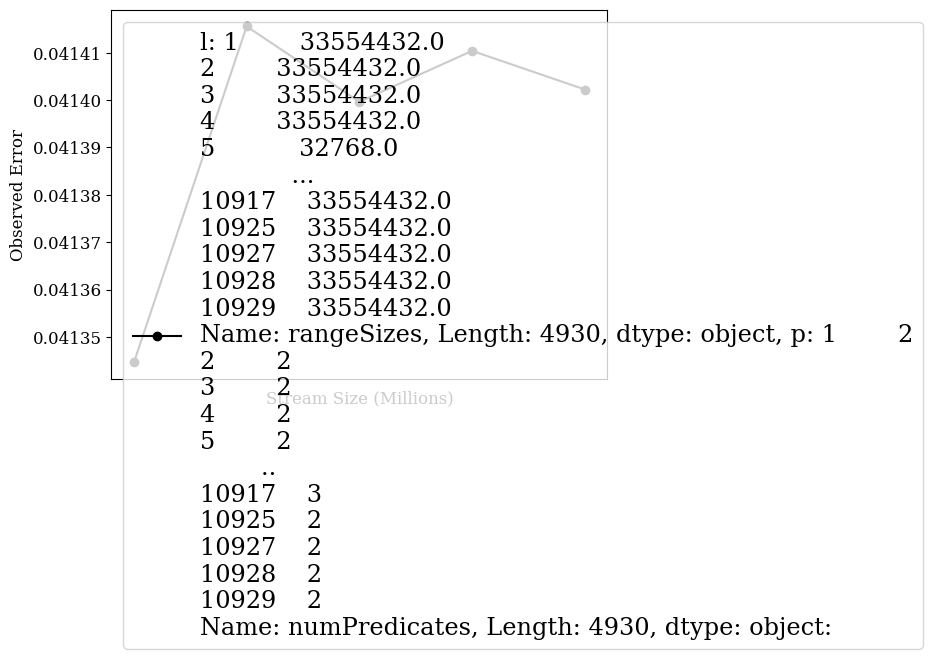

In [19]:
import matplotlib.ticker as ticker
dfs = df[df['setting'] == 'OmniSketch']
#dfs = dfs[dfs['numAttributes'] == dfs['numAttributes'].max()]
# Calculate average altEpsError per histSetting and streamSize
grouped_df = dfs.groupby(['histSetting2', 'B'])['altEpsError'].mean().reset_index()

# Set up the plot
fig, ax = plt.subplots()
#ord_settings = ['$\\mathbb{S}1 (10 MB)$', '$\\mathbb{S}1 (50 MB)$', '$\\mathbb{S}1 (100 MB)$', '$\\mathbb{S}1 (200 MB)$']

# Iterate over unique histSettings
#for hist_setting in grouped_df['histSetting'].unique():
for hist_setting in dfs['histSetting2'].unique():

# Filter the data for the current histSetting
    style = histSetting_style_dict.get(hist_setting, {'marker': 'o', 'color':'black'})
    filtered_data = grouped_df[grouped_df['histSetting2'] == hist_setting]

    # Plot the data
    ax.plot(filtered_data['B'], filtered_data['altEpsError'],
            linestyle=aggr_dict['altEpsError'],
            color=style['color'],
            marker=style['marker'], label=hist_setting)

# Set labels and title
ax.set_xlabel('Stream Size (Millions)')
ax.set_ylabel('Observed Error')
#ax.set_title('Avg. abs error / N vs streamSize for sketch 1')

# Add a legend
ax.legend(loc='upper left', fontsize='x-large')

# Set x-axis range from 0.5e7 to 2e7
#ax.set_xlim(5077343, 1.1e8)
#ax.set_ylim(0, 4e-4)
#plt.xticks(range(x_ticks[0], x_ticks[-1]))
# Set x-axis ticker and formatter
#ax.xaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.xaxis.set_major_formatter(ticker.MultipleLocator(base=1e6))
#ticker.MultipleLocator(base=1e6)
#plt.xticks(range(1000000, 8000000))
#ax.set_ylim(0, 3.5e-4)
#ax.yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
#ax.yaxis.set_major_formatter()
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1e7))  # Set ticks at every 1e6
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1e6)}'))
#ax.text(1.2e8, 0, '$\cdot 10^7$', fontsize=10, color='black', ha='right', va='top')  # Add custom annotation at bottom right

fig.savefig(folder_name + "{}_{}.pdf".format("RangeQueries", dataset), format="pdf", bbox_inches="tight" )


# Display the plot
plt.show()

In [98]:
df['numPredicates'].unique()

array([2, 3, 4], dtype=int64)

In [127]:
queries = pd.read_csv("output/queries_SNMP_N=8262313_range.csv")

In [146]:
x = queries['numPredicates'].value_counts()
for i in range(len(x)):
    y = x.index[i].replace('[', '').replace(']', '').split(', ')
    if (len(y) ==2):
        print("y: {}, count {}".format(y, x[i]))

y: ['14', '12'], count 57
y: ['8', '12'], count 51
y: ['9', '12'], count 49
y: ['12', '14'], count 48
y: ['12', '8'], count 47
y: ['15', '12'], count 46
y: ['12', '9'], count 44
y: ['9', '8'], count 42
y: ['12', '13'], count 42
y: ['13', '12'], count 42
y: ['13', '8'], count 42
y: ['8', '13'], count 40
y: ['8', '9'], count 40
y: ['12', '15'], count 39
y: ['13', '9'], count 25
y: ['15', '14'], count 24
y: ['15', '8'], count 24
y: ['9', '13'], count 22
y: ['8', '15'], count 20
y: ['8', '14'], count 19
y: ['14', '8'], count 17
y: ['14', '15'], count 12
y: ['15', '9'], count 9
y: ['13', '15'], count 9
y: ['12', '10'], count 9
y: ['9', '14'], count 8
y: ['10', '12'], count 8
y: ['14', '9'], count 8
y: ['15', '13'], count 7
y: ['13', '14'], count 6
y: ['9', '15'], count 6
y: ['11', '12'], count 4
y: ['14', '13'], count 4
y: ['10', '13'], count 3
y: ['12', '11'], count 2
y: ['11', '8'], count 2
y: ['10', '11'], count 2
y: ['8', '10'], count 2
y: ['13', '10'], count 1
y: ['15', '11'], count 1


In [149]:
x = queries['numPredicates'].value_counts()
for i in range(len(x)):
    y = x.index[i].replace('[', '').replace(']', '').split(', ')
    if (len(y) ==3):
        print("y: {}, count {}".format(y, x[i]))

y: ['9', '12', '8'], count 4
y: ['14', '15', '12'], count 4
y: ['13', '12', '9'], count 4
y: ['12', '14', '15'], count 3
y: ['12', '13', '8'], count 3
y: ['13', '9', '8'], count 3
y: ['9', '8', '13'], count 3
y: ['15', '14', '12'], count 3
y: ['12', '8', '13'], count 3
y: ['12', '9', '13'], count 3
y: ['14', '12', '15'], count 3
y: ['13', '8', '9'], count 2
y: ['13', '12', '8'], count 2
y: ['9', '13', '12'], count 2
y: ['13', '15', '12'], count 2
y: ['8', '15', '12'], count 2
y: ['13', '14', '12'], count 2
y: ['12', '9', '8'], count 2
y: ['14', '9', '8'], count 2
y: ['12', '14', '13'], count 2
y: ['9', '8', '12'], count 2
y: ['9', '8', '15'], count 2
y: ['8', '13', '9'], count 2
y: ['9', '14', '8'], count 2
y: ['12', '15', '9'], count 2
y: ['13', '12', '14'], count 2
y: ['15', '13', '8'], count 1
y: ['13', '8', '12'], count 1
y: ['9', '8', '14'], count 1
y: ['15', '12', '14'], count 1
y: ['14', '13', '12'], count 1
y: ['9', '14', '12'], count 1
y: ['9', '12', '15'], count 1
y: ['13', '